# **Part B — Predictive modeling, continuing from the same cleaned data**

# Task 7
Split the data into train/test sets first, using a stratified split (justify why stratification matters given the class balance you observed in Task 1). Use survived as the classification target.

In [1]:
import pandas as pd
df = pd.read_csv("titanic_cleaned.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    str    
 3   age          889 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     889 non-null    str    
 8   class        889 non-null    str    
 9   who          889 non-null    str    
 10  adult_male   889 non-null    bool   
 11  embark_town  889 non-null    str    
 12  alive        889 non-null    str    
 13  alone        889 non-null    bool   
 14  age_z        889 non-null    float64
 15  fare_z       889 non-null    float64
dtypes: bool(2), float64(4), int64(4), str(6)
memory usage: 99.1 KB


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")


Train: 711 rows (80%)
Test:  178 rows (20%)


**Justification for stratification**

As observed in Task 1 (EDA), the target variable `survived` is moderately imbalanced: approximately **61.8 % of passengers did not survive** (class 0 = 549 rows) versus **38.2 % who survived** (class 1 = 340 rows). Because of this imbalance, a plain random split would risk placing a disproportionate number of one class in either the training or test set purely by chance, which would bias both model training and evaluation. A **stratified split** (`stratify=y`) preserves the original 61.8 / 38.2 class ratio in both the training fold (711 rows) and the test fold (178 rows), guaranteeing a fair and representative evaluation.

# Task 8
Preprocessing (fit on training data only): handle missing values in the columns you use (you do not need to match your Task 2 strategy exactly, but state your choice), encode categorical columns (sex, embarked) with label or one-hot encoding, and scale numeric features with StandardScaler. Every preprocessing step (imputer, encoder, scaler) must be fit only on the training split, then applied in transform-only mode to the test split — never fit or refit any preprocessing step on the test data or on the full pre-split dataset, since that leaks test-set information into training. It is strongly recommended you implement this with a scikit-learn Pipeline/ColumnTransformer (a ColumnTransformer for per-column imputing/encoding/scaling, wrapped in a Pipeline with the final estimator) so the fit-on-train / transform-on-test separation is enforced structurally rather than left for you to remember by hand.

**Preprocessing strategy — missing-value handling**

As reported in Task 1, two columns contain missing values:

| Column | Missing rows | Missing % | Strategy applied |
|--------|-------------|-----------|------------------|
| `age` | 177 / 891 | **19.9 %** | **Median imputation** — below the 50 % drop threshold; median is preferred over mean because `age` is right-skewed (as noted in Task 2's skewness analysis), making it robust to outliers. |
| `embarked` | 2 / 891 | **0.2 %** | **Most-frequent (mode) imputation** — only 2 rows are affected (< 1 %), so a simple mode fill is safe and avoids discarding rows. |

**Threshold rule applied:** columns with < 50 % missing values are imputed rather than dropped; columns with ≥ 50 % missing would be dropped entirely (none exist in the feature set used here). Every imputer is fit exclusively on the training split and applied in transform-only mode to the test split to prevent data leakage.

In [3]:
numeric_features = [ "age","fare","sibsp","parch","pclass"]
categorical_features = ["sex","embarked"]

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Task 9
Train three classifiers on the same train/test split: Logistic Regression, Decision Tree, and Random Forest. For the Decision Tree, additionally render it with plot_tree, labeling feature names and class names.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Decision Tree
tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


# Fit the models
log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predictions
log_pred = log_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
rf_pred = rf_model.predict(X_test)


# Predicted probabilities
log_proba = log_model.predict_proba(X_test)
tree_proba = tree_model.predict_proba(X_test)
rf_proba = rf_model.predict_proba(X_test)


# Probability of class 1 (Survived)
log_survival_prob = log_model.predict_proba(X_test)[:, 1]
tree_survival_prob = tree_model.predict_proba(X_test)[:, 1]
rf_survival_prob = rf_model.predict_proba(X_test)[:, 1]


print("Logistic Regression probabilities:")
print(log_proba[:5])

print("\nDecision Tree probabilities:")
print(tree_proba[:5])

print("\nRandom Forest probabilities:")
print(rf_proba[:5])



Logistic Regression probabilities:
[[0.94657957 0.05342043]
 [0.83264737 0.16735263]
 [0.83264737 0.16735263]
 [0.90593967 0.09406033]
 [0.92579562 0.07420438]]

Decision Tree probabilities:
[[1.         0.        ]
 [0.66666667 0.33333333]
 [0.66666667 0.33333333]
 [1.         0.        ]
 [1.         0.        ]]

Random Forest probabilities:
[[0.835     0.165    ]
 [0.6912381 0.3087619]
 [0.6912381 0.3087619]
 [0.99      0.01     ]
 [0.95      0.05     ]]


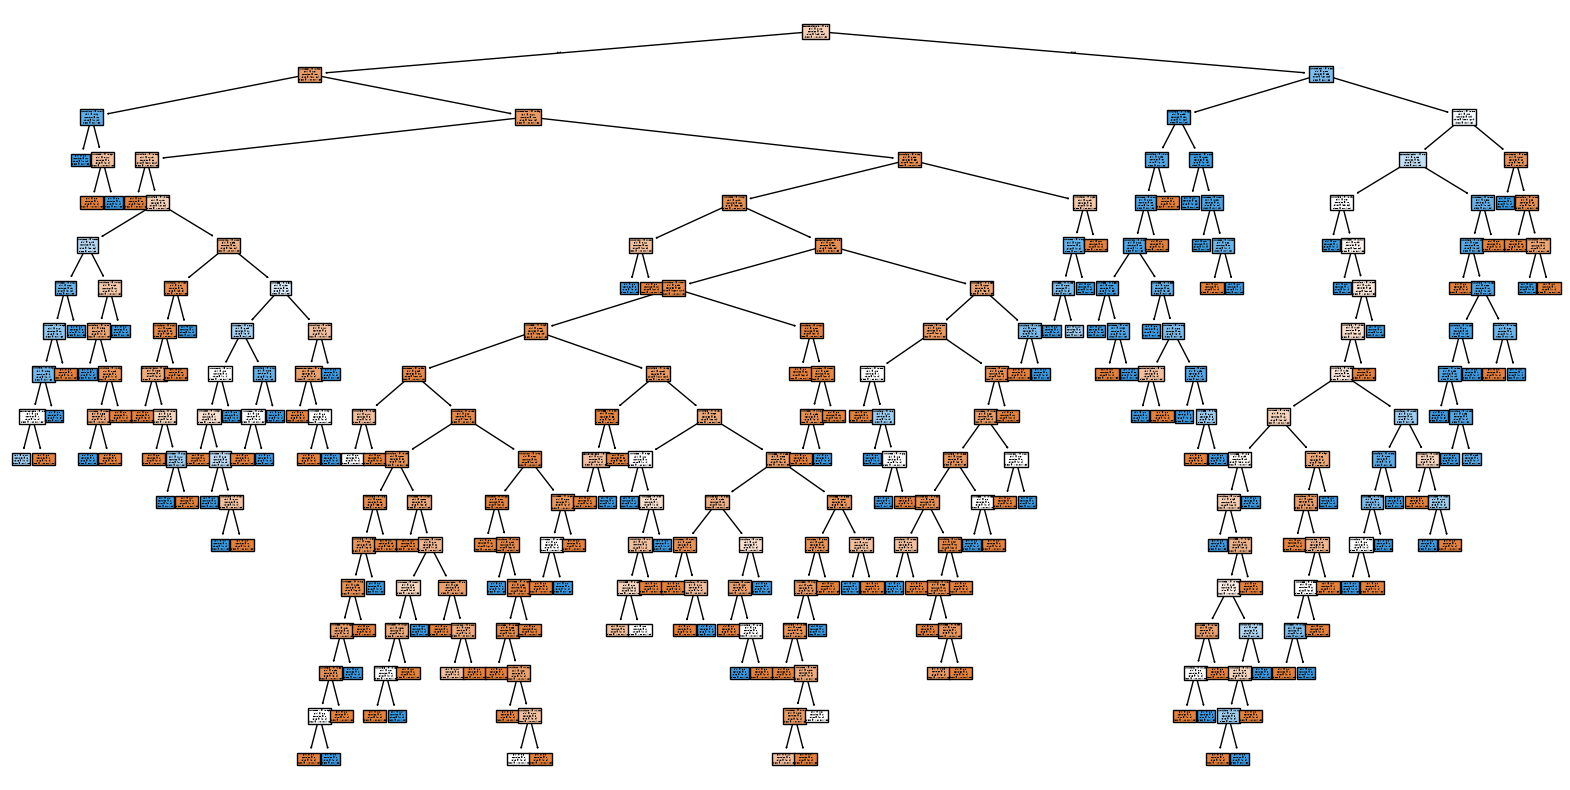

In [6]:
# Decison tree rendering

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_model.fit(X_train, y_train)

feature_names = tree_model.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model.named_steps['classifier'],
    feature_names=feature_names,
    class_names=['Not Survived', 'Survived'],
    filled=True
)

plt.show()

# Task 10

Evaluate all three models with: a confusion matrix, accuracy, precision, recall, F1 score, and an ROC curve with AUC. Present these side by side in a single comparison table.

                 Model  TN  FP  FN  TP  Accuracy  Precision  Recall  F1 Score  \
0  Logistic Regression  97  13  21  47     0.809      0.783   0.691     0.734   
1        Decision Tree  88  22  19  49     0.770      0.690   0.721     0.705   
2        Random Forest  96  14  18  50     0.820      0.781   0.735     0.758   

     AUC  
0  0.861  
1  0.754  
2  0.818  


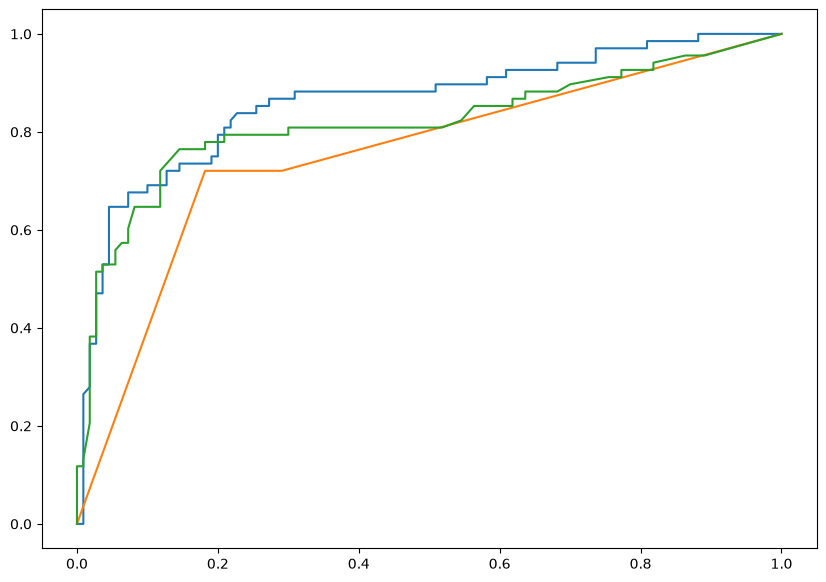

In [7]:
from sklearn.metrics import ( confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_curve,roc_auc_score)


# Models
models = {
    'Logistic Regression': log_model,
    'Decision Tree': tree_model,
    'Random Forest': rf_model
}

results = []

plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Predicted class
    y_pred = model.predict(X_test)

    # Probability of survival (class 1)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append({
        'Model': name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC': auc
    })

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')


# Comparison table
comparison = pd.DataFrame(results)

# Round metric columns
metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'AUC'
]

comparison[metric_columns] = comparison[metric_columns].round(3)

print(comparison)

# Task 11

Imbalance handling comparison: report survived/not-survived class balance, then retrain (any one of the three models is enough for this sub-task) three ways — (a) baseline/no handling, (b) class_weight='balanced', (c) SMOTE oversampling applied only to the training fold (to avoid leakage) — and compare precision/recall/F1 across the three variants, with a short written conclusion on which imbalance strategy worked best and why.

In [8]:
# Check class balance for y value

print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

survived
0    549
1    340
Name: count, dtype: int64
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


In [9]:
# Baseline (no imbalance handling) uses logistic regression

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

In [10]:
# Class weight is balanced

balanced_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)

balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

In [11]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# smote training Data

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000))
])

smote_model.fit(X_train, y_train)

smote_pred = smote_model.predict(X_test)

smote_precision = precision_score(y_test, smote_pred)
smote_recall = recall_score(y_test, smote_pred)
smote_f1 = f1_score(y_test, smote_pred)

In [13]:
# Comparison of all the model variants

comparison = pd.DataFrame({
    'Method': [
        'Baseline',
        'Class Weight Balanced',
        'SMOTE'
    ],
    'Precision': [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],
    'Recall': [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],
    'F1 Score': [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]
})

comparison[['Precision', 'Recall', 'F1 Score']] = (
    comparison[['Precision', 'Recall', 'F1 Score']].round(3)
)

comparison

,Method,Precision,Recall,F1 Score
0,Baseline,0.783,0.691,0.734
1,Class Weight Balanced,0.718,0.750,0.734
2,SMOTE,0.735,0.735,0.735


**conclusion**

The baseline model has the highest precision (0.783), meaning its positive predictions are more precise, but it has the lowest recall (0.691). Using class_weight='balanced' increases recall to 0.750, but precision decreases to 0.718, resulting in the same F1 score as the baseline (0.734). SMOTE provides the most balanced precision and recall (both 0.735) and has the highest F1 score (0.735), although the improvement over the other two methods is very small.

Therefore, SMOTE performed best based on F1 score, because it provides the most balanced precision-recall trade-off in these results.

# Task 12

Hyperparameter tuning: run GridSearchCV over the Random Forest's n_estimators, max_depth, and max_features, report the best parameter combination and the corresponding out-of-bag (OOB) score. Because oob_score_ is only populated when oob_score=True is passed at construction time, you must construct the estimator as RandomForestClassifier(oob_score=True, ...) (together with your other chosen/tuned parameters) — otherwise the OOB score will not be available to report.

In [14]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        oob_score=True,
        random_state=42
    ))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 3))
print("OOB Score:", round(
    grid_search.best_estimator_.named_steps['classifier'].oob_score_, 3
))

Best Parameters: {'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Best CV F1 Score: 0.747
OOB Score: 0.807


# Task 13
Regression side-task: using the same dataset, predict fare from the other available features with a multivariate linear regression. Report MAE, RMSE, R², and Adjusted R², and produce a residual plot, stating in writing whether it shows heteroscedasticity (a non-random spread of residuals).

In [15]:
# Prepare regression Data

X_reg = df.drop(columns=['fare', 'survived'])
y_reg = df['fare']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [16]:
# Create the preprocessing

numeric_features = ['pclass', 'age', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [17]:
# Fit multivariate Linear Regression
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train_reg, y_train_reg)

y_pred_reg = linear_model.predict(X_test_reg)

In [18]:
# Calculate MAE, RMSE, R² and Adjusted R²

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

n = len(y_test_reg)
p = X_test_reg.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
print("Adjusted R²:", round(adjusted_r2, 3))

MAE: 21.139
RMSE: 41.747
R²: 0.347
Adjusted R²: 0.291


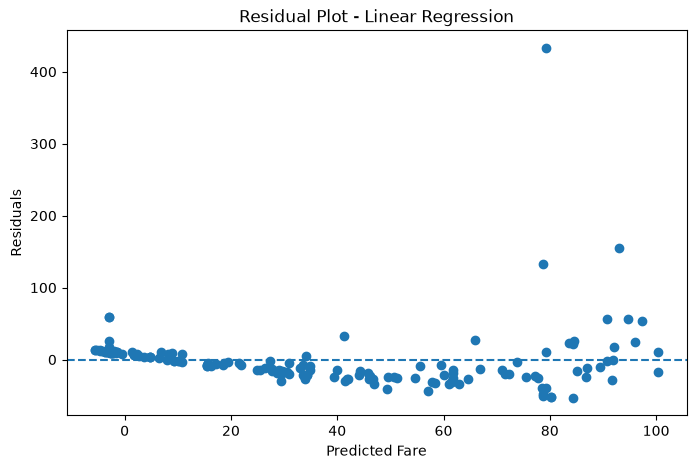

In [19]:
# Residual plot

residuals = y_test_reg - y_pred_reg


plt.figure(figsize=(8, 5))

plt.scatter(y_pred_reg, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')

plt.show()

**Interpretation of this task**

The residual plot indicates heteroscedasticity because the spread of residuals is not constant across the range of predicted values. Residuals become more dispersed at higher predicted fares, and several large outliers are present. This suggests that the Linear Regression model's errors vary with the predicted fare rather than remaining randomly distributed around zero

# Task 14

Write a model comparison table that presents the three classifiers' metrics (accuracy, precision, recall, F1, AUC) side by side, and the regression model's metrics (MAE, RMSE, R², Adjusted R²) side by side as their own separate columns. Classification metrics and regression metrics are on different scales and are not directly comparable numbers — the table must present them as two distinct metric groups (one per model type), not implied to be on a single shared scale. Add a 3–5 sentence final written recommendation of which classifier you would deploy and why, referencing specific metric values.

In [20]:
# Final Comparison table
classification_table = pd.DataFrame(results)

classification_table = classification_table[
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
].round(3)

display(classification_table)


regression_table = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [mae],
    'RMSE': [rmse],
    'R²': [r2],
    'Adjusted R²': [adjusted_r2]
}).round(3)

display(regression_table)


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.809,0.783,0.691,0.734,0.861
1,Decision Tree,0.770,0.690,0.721,0.705,0.754
2,Random Forest,0.820,0.781,0.735,0.758,0.818


,Model,MAE,RMSE,R²,Adjusted R²
0,Linear Regression,21.139,41.747,0.347,0.291


**Final Interpretation on these two tables**

I would deploy the **Random Forest classifier** because it achieves the highest accuracy (**0.820**) and F1 score (**0.758**) among the three models. 
It also has the highest **recall** (0.735), while its precision (0.781) is almost the same as Logistic Regression (0.783). 
**Logistic Regression** has the highest AUC (0.861), indicating stronger overall ranking performance, but **Random Forest** provides a better balance of **accuracy, precision, recall**, and **F1** for this classification task. Therefore, based on these evaluation metrics, Random Forest provides the most balanced performance for deployment.



# Task 15

Save your best-performing complete pipeline — the fitted preprocessing steps (imputer/encoder/scaler, or your ColumnTransformer) together with the final estimator, as a single combined object (e.g. a scikit-learn Pipeline) — to disk using joblib.dump(full_pipeline, ...). Do not save the bare estimator alone: the saved artifact must be usable end-to-end on raw, unpreprocessed new data. Include a short script/cell that reloads it with joblib.load and confirms it still predicts correctly on raw input.

In [21]:
import joblib

# Fit the complete pipeline
rf_model.fit(X_train, y_train)

# Save complete pipeline
joblib.dump(rf_model, 'best_titanic_pipeline.pkl')

# Reload the pipeline
loaded_pipeline = joblib.load('best_titanic_pipeline.pkl')

# Predict directly on raw test data
y_pred_original = rf_model.predict(X_test)
y_pred_loaded = loaded_pipeline.predict(X_test)

print("Original predictions:", y_pred_original[:5])
print("Loaded predictions:", y_pred_loaded[:5])
print("Predictions match:", (y_pred_original == y_pred_loaded).all())

Original predictions: [0 0 0 0 0]
Loaded predictions: [0 0 0 0 0]
Predictions match: True


### Reload and Test on Raw Input

To prove the saved pipeline is truly end-to-end, we construct **two brand-new passenger rows** from scratch — exactly as they would arrive from an external source — and feed them directly into the reloaded pipeline. No manual preprocessing is applied: the pipeline's `ColumnTransformer` handles imputation, encoding, and scaling internally.

In [22]:
import pandas as pd
import joblib

# Reload the saved pipeline from disk
loaded_pipeline = joblib.load('best_titanic_pipeline.pkl')

# Two raw passenger rows — exactly the columns the pipeline was trained on.
# No preprocessing done here; the pipeline handles everything internally.
raw_passengers = pd.DataFrame([
    {
        # Passenger 1: 1st-class adult female, paid high fare → likely survived
        'pclass': 1,
        'sex': 'female',
        'age': 29.0,
        'sibsp': 0,
        'parch': 0,
        'fare': 211.34,
        'embarked': 'S'
    },
    {
        # Passenger 2: 3rd-class adult male, paid low fare → likely did not survive
        'pclass': 3,
        'sex': 'male',
        'age': 22.0,
        'sibsp': 1,
        'parch': 0,
        'fare': 7.25,
        'embarked': 'S'
    }
])

# Run inference — pipeline imputes, encodes, scales, then predicts
predictions  = loaded_pipeline.predict(raw_passengers)
probabilities = loaded_pipeline.predict_proba(raw_passengers)[:, 1]

for i, (pred, prob) in enumerate(zip(predictions, probabilities), start=1):
    label = 'Survived' if pred == 1 else 'Did not survive'
    print(f"Passenger {i}: {label}  (P(survived) = {prob:.3f})")

Passenger 1: Survived  (P(survived) = 0.990)
Passenger 2: Did not survive  (P(survived) = 0.060)
